In [1]:
   !pip install -q dm-haiku optax

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 5.2 MB/s eta 0:00:0000:0100:01


In [2]:
# %% [code]
# ==============================================================================
# Cell 1: Environment Setup & Precision Configuration (V17.8)
#
# RELEASE NOTES (V17.8 — POST-SMOKE-TEST PERFORMANCE & CONVERGENCE FIX):
# This release directly responds to the empirical smoke-test results of V17.7:
#   1. Resolves the catastrophic 5-hour runtime bottleneck in L-BFGS by properly
#      managing device memory and array synchronization between JAX and SciPy.
#   2. Prepares infrastructure for fixing the 1D spatial collapse of the inverted
#      bed friction field (Cf) and mitigating the 20x loss explosion at Phase 2.
#   3. Maintains JAX 64-bit precision (Float64) essential for hydrodynamic momentum
#      and gravity wave propagation balances.
# ==============================================================================

import os
import time
import pickle
import warnings
import numpy as np
import scipy.optimize
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# --- Advanced XLA and GPU Memory Allocation Flags ---
# Preallocation is disabled to allow seamless memory sharing between JAX JIT
# kernels and SciPy's CPU-based host arrays without triggering CUDA OOM errors.
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.85"

# Suppress noisy external library warnings while retaining critical runtime alerts
warnings.filterwarnings("ignore", category=UserWarning, module="jax")
warnings.filterwarnings("ignore", category=FutureWarning)

import jax
import jax.numpy as jnp
from jax.flatten_util import ravel_pytree
import optax
import haiku as hk

# Enforce strict 64-bit precision across all JAX operations
jax.config.update("jax_enable_x64", True)

# Verify execution backend
active_backend = jax.default_backend()
devices = jax.devices()

print("=" * 80)
print("🚀 V17.8 HYDRODYNAMIC PINN INVERSION ENGINE INITIALIZED")
print(f"   • JAX Backend: {active_backend.upper()} ({len(devices)} device(s) detected: {devices[0].device_kind})")
print("   • Precision: Float64 (64-bit double precision enforced globally)")
print("   • Objective: Rectifying 1D spatial friction collapse & optimizing L-BFGS throughput")
print("=" * 80)

🚀 V17.8 HYDRODYNAMIC PINN INVERSION ENGINE INITIALIZED
   • JAX Backend: GPU (2 device(s) detected: Tesla T4)
   • Precision: Float64 (64-bit double precision enforced globally)
   • Objective: Rectifying 1D spatial friction collapse & optimizing L-BFGS throughput


In [3]:
# %% [code]
# ==============================================================================
# Cell 2: Advanced Configuration & Scaling Namespaces (V17.8)
#
# CRITICAL REVISIONS & FIXES IN V17.8:
#   1. FOURIER_SIGMA_FRIC raised from 3.0 to 8.0: Solves the fatal 1D spatial
#      collapse where the friction net failed to resolve y-dimension features.
#   2. L-BFGS Performance Overhaul: Chunk size raised from 500 to 2500, physics
#      points budgeted at 10,000, and max iterations capped at 300 for smoke-test
#      (eliminating the catastrophic 5-hour runtime bottleneck).
#   3. Loss Weight Schedules: Parameterized baseline and target loss weights to
#      allow smooth ramping across WARM_TRANSITION_EPOCHS, eliminating the 20x
#      loss explosion observed at epoch 600.
#   4. Smoke-test budget expanded to 2000 epochs (800 Phase 1 + 200 Warm Ramp +
#      1000 Phase 2) to guarantee sufficient friction optimization iterations.
# ==============================================================================

import numpy as np


class config:
    # --------------------------------------------------------------------------
    # 1. Fundamental Physical Scales & Oceanographic Dimensions
    # --------------------------------------------------------------------------
    G_REAL = 9.81              # Gravitational acceleration [m/s^2]
    L_REF = 100_000.0          # Characteristic basin scale: 100 km (Strait width)
    H_REF = 100.0              # Reference maximum water depth [m]
    RHO_WATER = 1025.0         # Density of seawater [kg/m^3]

    # Derived wave speed and dynamic advective/gravity time-scale
    C_WAVE = np.sqrt(G_REAL * H_REF)             # Shallow wave celerity: ~31.32 m/s
    TIME_SCALE_TAU = L_REF / C_WAVE              # Dynamic time scale: ~3192.75 s (~53.2 min)

    # --------------------------------------------------------------------------
    # 2. Dual-Branch Neural Architecture & Fourier Feature Engineering
    # --------------------------------------------------------------------------
    NN_HYDRO_LAYERS = [3, 128, 128, 128, 128, 3]   # (t, x, y) -> (h, u, v)
    NN_FRIC_LAYERS = [2, 128, 128, 128, 1]         # (x, y)    -> Cf_raw
    NN_ACTIVATION = 'tanh'

    FOURIER_SIGMA_HYDRO = 1.0     # Smooth wave propagation features
    
    # 💥 V17.8 CRITICAL FIX: Raised from 3.0 to 8.0.
    # Enables spatial resolution of sub-mesoscale lithological features down to 
    # ~5 km across both x and y dimensions, overcoming 1D spectral collapse.
    FOURIER_SIGMA_FRIC = 8.0

    # --------------------------------------------------------------------------
    # 3. Execution Mode Switch & Epoch Budgets
    # --------------------------------------------------------------------------
    SMOKE_TEST = True            # Set False for final production run

    # Physical simulation horizon
    T_MAX_PHYSICAL_FULL = 8.0 * 24.0 * 3600.0       # 8 days (production)
    T_MAX_PHYSICAL_SMOKETEST = 3.0 * 24.0 * 3600.0  # 3 days (diagnostic smoke-test)
    T_MAX_PHYSICAL = T_MAX_PHYSICAL_SMOKETEST if SMOKE_TEST else T_MAX_PHYSICAL_FULL
    T_MAX_NORM = T_MAX_PHYSICAL / TIME_SCALE_TAU
    CAUSAL_EPSILON = 3.0 / T_MAX_NORM

    # Training schedule: Full run
    EPOCHS_ADAM_FULL = 32000
    PHASE1_EPOCHS_FULL = 12000
    WARM_TRANSITION_EPOCHS_FULL = 1000

    # Training schedule: Smoke test (re-balanced for friction recovery)
    EPOCHS_ADAM_SMOKETEST = 2000
    PHASE1_EPOCHS_SMOKETEST = 800
    WARM_TRANSITION_EPOCHS_SMOKETEST = 200

    EPOCHS_ADAM = EPOCHS_ADAM_SMOKETEST if SMOKE_TEST else EPOCHS_ADAM_FULL
    PHASE1_EPOCHS = PHASE1_EPOCHS_SMOKETEST if SMOKE_TEST else PHASE1_EPOCHS_FULL
    WARM_TRANSITION_EPOCHS = WARM_TRANSITION_EPOCHS_SMOKETEST if SMOKE_TEST else WARM_TRANSITION_EPOCHS_FULL

    ADAM_LR_HYDRO = 1e-3
    ADAM_LR_FRIC = 2e-4           # Slightly elevated target LR for responsive friction learning
    BASE_SEED = 42
    LOSS_LOG_INTERVAL = 50

    # Optimizer reset at transition boundary to purge Phase 1 momentum
    RESET_FRICTION_OPTIMIZER_AT_PHASE2 = True

    # --------------------------------------------------------------------------
    # 4. Multi-Task Loss Weighting & Ramp Configuration
    # --------------------------------------------------------------------------
    # Staged loss weights to prevent optimization shock
    LAMBDA_DATA_PHASE1 = 20.0
    LAMBDA_DATA_PHASE2 = 100.0
    LAMBDA_SWE_PHASE1 = 1.0
    LAMBDA_SWE_PHASE2 = 10.0
    
    LAMBDA_TV = 1e-5             # Slightly reinforced TV penalty to counter sigmoid saturation
    LAMBDA_REG_UV = 100.0
    LAMBDA_BC = 100.0
    HUBER_DELTA = 0.05

    # --------------------------------------------------------------------------
    # 5. Friction Parameterization & Regularization Bounds
    # --------------------------------------------------------------------------
    CF_MIN = 0.0015
    CF_RANGE = 0.0065            # Strict range: [0.0015, 0.0080]
    EPS_NORM = 0.1 / H_REF       # Numerical depth protection floor (~1 mm normalized)

    # --------------------------------------------------------------------------
    # 6. Wind & Adaptive Topographic Viscosity
    # --------------------------------------------------------------------------
    WIND_STRESS_MAX = 0.5        # N/m^2
    WIND_PERIOD_PHYSICAL = 4.0 * 24.0 * 3600.0   # 96.0 hours (~7.7x M2 tide)
    WIND_ROTATION_PHASE_RAD = np.pi / 2.0        # 90-degree rotating vector proxy
    SPINUP_DURATION_PHYSICAL = 12.0 * 3600.0
    SAVE_INTERVAL_STEPS = 3600                   # 1 hour intervals (dt=1s)
    MIN_WIND_TIDE_PERIOD_RATIO = 3.0

    NU_BASE_PHYSICAL = 2.0       # m^2/s
    NU_MAX_PHYSICAL = 20.0       # m^2/s
    NU_TRANSITION_K = 5.0
    NU_FD_PHYSICAL = 40.0        # Ground-truth solver artificial diffusion (Cell 3 only)

    ENABLE_WIND = True
    ENABLE_DIFFUSION = True

    # --------------------------------------------------------------------------
    # 7. Observation Sparsification & Decoupled Collocation Pools
    # --------------------------------------------------------------------------
    ENABLE_SATELLITE_SPARSIFICATION = True
    SAT_N_TRACKS = 4
    SAT_TRACK_ANGLE_DEG = 80.0
    SAT_TRACK_HALF_WIDTH_KM = 2.0
    SAT_TRACK_DRIFT_KM_PER_SNAPSHOT = 1.7
    ENABLE_DECOUPLED_COLLOCATION = True
    PHYSICS_COLLOCATION_BATCH_SIZE = 1000

    # --------------------------------------------------------------------------
    # 8. L-BFGS-B Quasi-Newton High-Throughput Configuration
    # --------------------------------------------------------------------------
    # 💥 V17.8 FIXES:
    # 1. Point budget set to 10,000 (statistically dense, computationally lightweight).
    # 2. Chunk size set to 2500: evaluated in only 4 vector calls, minimizing JAX-SciPy sync.
    # 3. Max iterations strictly bounded to eliminate 5-hour runtimes.
    LBFGS_MAX_DATA_POINTS = 5000
    LBFGS_MAX_PHYSICS_POINTS = 10000
    LBFGS_CHUNK_SIZE = 2500

    LBFGS_MAX_ITER_SMOKETEST = 300
    LBFGS_MAX_ITER_FULL = 1500
    LBFGS_MAX_ITER = LBFGS_MAX_ITER_SMOKETEST if SMOKE_TEST else LBFGS_MAX_ITER_FULL
    LBFGS_FTOL = 1e-9
    LBFGS_GTOL = 1e-5

    EVALUATE_ADAM_STAGE_SEPARATELY = True

    # --------------------------------------------------------------------------
    # 9. Scenario & Run Identification
    # --------------------------------------------------------------------------
    @staticmethod
    def scenario_tag():
        w = "on" if config.ENABLE_WIND else "off"
        d = "on" if config.ENABLE_DIFFUSION else "off"
        return f"wind_{w}_diff_{d}"

    @staticmethod
    def run_id():
        return f"{config.scenario_tag()}{'_smoketest' if config.SMOKE_TEST else ''}"

    DATA_PATH = 'data/twin_experiment_v17_smoketest.npz' if SMOKE_TEST else 'data/twin_experiment_v17.npz'


class utils_scaling:
    """Non-dimensionalization conversion factors for primitive 2D SWE."""
    G_STAR = (config.G_REAL * config.H_REF * (config.TIME_SCALE_TAU**2)) / (config.L_REF**2)
    FRICTION_SCALE = config.L_REF / config.H_REF
    WIND_SCALE = (config.TIME_SCALE_TAU**2) / (config.RHO_WATER * config.L_REF * config.H_REF)
    NU_SCALE = config.TIME_SCALE_TAU / (config.L_REF**2)
    NU_BASE_SCALED = config.NU_BASE_PHYSICAL * NU_SCALE
    NU_MAX_SCALED = config.NU_MAX_PHYSICAL * NU_SCALE

    @staticmethod
    def normalize_spatial(x_real, y_real):
        return x_real / config.L_REF, y_real / config.L_REF

    @staticmethod
    def normalize_temporal(t_real):
        return t_real / config.TIME_SCALE_TAU

    @staticmethod
    def normalize_kinematics(h_real, u_real, v_real):
        h_star = h_real / config.H_REF
        v_scale = config.L_REF / config.TIME_SCALE_TAU
        u_star = u_real / v_scale
        v_star = v_real / v_scale
        return h_star, u_star, v_star

    @staticmethod
    def denormalize_outputs(h_star, u_star, v_star, Cf_star):
        h_real = h_star * config.H_REF
        v_scale = config.L_REF / config.TIME_SCALE_TAU
        u_real = u_star * v_scale
        v_real = v_star * v_scale
        return h_real, u_real, v_real, Cf_star


# Diagnostic printout on cell execution
print("=" * 80)
print("⚙️  CONFIGURATION LOCKED: V17.8 TUNED HYDRAULIC ENGINE")
print(f"   • Mode: {'🧪 SMOKE TEST (Diagnostic Validation)' if config.SMOKE_TEST else '🚀 PRODUCTION FULL RUN'}")
print(f"   • Data Path: {config.DATA_PATH}")
print(f"   • Spatial Friction Fourier Sigma: {config.FOURIER_SIGMA_FRIC:.1f} (High-frequency 2D enabled)")
print(f"   • Training Horizon: {config.EPOCHS_ADAM} Adam epochs ({config.PHASE1_EPOCHS} Lock / {config.WARM_TRANSITION_EPOCHS} Ramp)")
print(f"   • L-BFGS Budget: {config.LBFGS_MAX_PHYSICS_POINTS} points | Chunk size: {config.LBFGS_CHUNK_SIZE} (4 chunks/iter)")
print(f"   • L-BFGS Max Iterations: {config.LBFGS_MAX_ITER} (Runtime bounded to ~minutes)")
print("=" * 80)

⚙️  CONFIGURATION LOCKED: V17.8 TUNED HYDRAULIC ENGINE
   • Mode: 🧪 SMOKE TEST (Diagnostic Validation)
   • Data Path: data/twin_experiment_v17_smoketest.npz
   • Spatial Friction Fourier Sigma: 8.0 (High-frequency 2D enabled)
   • Training Horizon: 2000 Adam epochs (800 Lock / 200 Ramp)
   • L-BFGS Budget: 10000 points | Chunk size: 2500 (4 chunks/iter)
   • L-BFGS Max Iterations: 300 (Runtime bounded to ~minutes)


In [4]:
# %% [code]
# ==============================================================================
# Cell 3: High-Fidelity Ground-Truth Twin Data Generator (V17.8)
#
# NUMERICAL ATTRIBUTES & INTEGRITY SAFEGUARDS:
#   1. Unconditionally Stable Advection: First-order upwind spatial differencing
#      for nonlinear momentum advection, guaranteeing 0% safety-valve activations.
#   2. Dynamic 2D Vorticity: Curl-inducing rotating wind stress forcing paired
#      with an asymmetric bathymetric seamount to generate rich 2D transverse shears.
#   3. Dual-Feature Bed Friction Mosaic: Two spatially separated lithological
#      zones (Rock outcrop @ 0.0070, Coastal reef shelf @ 0.0060) on a mud plain
#      (0.0025) with verified Gaussian smoothing (sigma=1.0).
#   4. Provenance Tag: Updated to 'V17.8_high_fidelity_twin' for strict pipeline
#      version tracking and audit compliance.
# ==============================================================================

import os
import numpy as np
from scipy.ndimage import gaussian_filter


def _upwind_dfdx(f, u_adv, dx):
    """First-order upwind derivative of scalar/vector field `f` along the x-axis (axis=1),
    conditioned on the instantaneous sign of the advecting velocity `u_adv`."""
    fwd = np.empty_like(f)
    bwd = np.empty_like(f)
    fwd[:, :-1] = (f[:, 1:] - f[:, :-1]) / dx
    fwd[:, -1] = fwd[:, -2]
    bwd[:, 1:] = (f[:, 1:] - f[:, :-1]) / dx
    bwd[:, 0] = bwd[:, 1]
    return np.where(u_adv >= 0, bwd, fwd)


def _upwind_dfdy(f, v_adv, dy):
    """First-order upwind derivative of scalar/vector field `f` along the y-axis (axis=0),
    conditioned on the instantaneous sign of the advecting velocity `v_adv`."""
    fwd = np.empty_like(f)
    bwd = np.empty_like(f)
    fwd[:-1, :] = (f[1:, :] - f[:-1, :]) / dy
    fwd[-1, :] = fwd[-2, :]
    bwd[1:, :] = (f[1:, :] - f[:-1, :]) / dy
    bwd[0, :] = bwd[1, :]
    return np.where(v_adv >= 0, bwd, fwd)


def compute_satellite_visibility_mask(X, Y, snapshot_idx):
    """Generates synthetic along-track satellite observation swaths based on an inclined
    orbit geometry with systematic cross-track orbital drift."""
    theta = np.deg2rad(config.SAT_TRACK_ANGLE_DEG)
    proj = X * np.cos(theta) + Y * np.sin(theta)
    spacing = config.L_REF / config.SAT_N_TRACKS
    drift = snapshot_idx * config.SAT_TRACK_DRIFT_KM_PER_SNAPSHOT * 1000.0
    phase = np.mod(proj - drift, spacing)
    dist_to_nearest_track = np.minimum(phase, spacing - phase)
    return dist_to_nearest_track <= (config.SAT_TRACK_HALF_WIDTH_KM * 1000.0)


def generate_v17_synthetic():
    print("\n" + "=" * 80)
    print("🌊 EXECUTING GROUND-TRUTH SYNTHETIC TWIN GENERATOR (V17.8)")
    print("=" * 80)

    # --------------------------------------------------------------------------
    # 1. Spatial Domain & Mesh Grid Construction
    # --------------------------------------------------------------------------
    nx, ny = 100, 50
    dx = config.L_REF / nx                    # 1000.0 m
    dy = (config.L_REF / 2.0) / ny            # 1000.0 m
    g = config.G_REAL

    x = np.linspace(0, config.L_REF, nx)
    y = np.linspace(0, config.L_REF / 2.0, ny)
    X, Y = np.meshgrid(x, y)

    # --------------------------------------------------------------------------
    # 2. Asymmetric Bathymetric Relief & Spatial Gradients
    # --------------------------------------------------------------------------
    H_mean = -40.0
    bump_height = 25.0
    spread = (config.L_REF / 8.0)**2
    # Bathymetric bump positioned off-center (L_x/2, L_y/4) to stimulate 2D vorticity
    b_true = H_mean + bump_height * np.exp(
        -((X - config.L_REF / 2.0)**2 + (Y - config.L_REF / 4.0)**2) / spread
    )

    b_x_true = np.gradient(b_true, dx, axis=1)
    b_y_true = np.gradient(b_true, dy, axis=0)

    # High-order curvature tensors for exact adaptive diffusion derivation
    b_xx_true = np.gradient(b_x_true, dx, axis=1)
    b_xy_true = np.gradient(b_x_true, dy, axis=0)
    b_yy_true = np.gradient(b_y_true, dy, axis=0)

    # --------------------------------------------------------------------------
    # 3. True Bed Friction Mosaic (Ground-Truth Target Field)
    # --------------------------------------------------------------------------
    cf_true = np.full((ny, nx), 0.0025)  # Background silty-mud terrace
    
    # Feature 1: Central deep channel rocky sill (High friction)
    cf_true[(X > 0.60 * config.L_REF) & (Y < 0.30 * config.L_REF)] = 0.0070
    
    # Feature 2: Northern littoral reef shelf (Medium-high friction)
    cf_true[(X < 0.22 * config.L_REF) & (Y > 0.72 * (config.L_REF / 2.0))] = 0.0060
    
    # Smooth boundaries using verified stable scale (sigma=1.0 prevents A-grid checkerboard modes)
    cf_true = gaussian_filter(cf_true, sigma=1.0)

    # --------------------------------------------------------------------------
    # 4. Planetary & Tidal Boundary Forcing Parameters
    # --------------------------------------------------------------------------
    omega_earth = 7.2921e-5
    lat = 26.5 * (np.pi / 180.0)
    f_coriolis = 2.0 * omega_earth * np.sin(lat)

    T_TIDAL_M2 = 12.42 * 3600.0
    omega_tide = 2.0 * np.pi / T_TIDAL_M2
    omega_wind = 2.0 * np.pi / config.WIND_PERIOD_PHYSICAL

    dt = 1.0                                # 1-second explicit integration timestep
    T_total = config.T_MAX_PHYSICAL
    steps = int(T_total / dt)
    save_interval = config.SAVE_INTERVAL_STEPS
    SPINUP_DURATION = config.SPINUP_DURATION_PHYSICAL
    nu_FD = config.NU_FD_PHYSICAL

    print(f"   • Grid Resolution: {nx}x{ny} (dx = {dx:.1f} m, dy = {dy:.1f} m)")
    print(f"   • Time Horizon: {T_total/86400:.2f} days ({steps} steps @ dt = {dt}s)")
    print(f"   • Numerical Viscosity (nu_FD): {nu_FD:.1f} m^2/s | Spin-up: {SPINUP_DURATION/3600:.1f} hours")
    print(f"   • Rotating Wind Forcing: T_wind = {config.WIND_PERIOD_PHYSICAL/3600:.1f}h (Phase offset: 90 deg)")

    # --------------------------------------------------------------------------
    # 5. Explicit Time-Stepping Finite-Difference Loop
    # --------------------------------------------------------------------------
    h = np.zeros((ny, nx))
    u = np.zeros((ny, nx))
    v = np.zeros((ny, nx))

    history_h, history_u, history_v, history_t = [], [], [], []
    history_tau_x, history_tau_y = [], []
    history_sat_mask = []
    clip_events = 0

    for n in range(steps):
        t_curr = n * dt
        D = np.maximum(h - b_true, 0.1)

        dh_dx = np.gradient(h, dx, axis=1)
        dh_dy = np.gradient(h, dy, axis=0)

        speed = np.sqrt(u**2 + v**2 + 1e-6)
        fric_x = cf_true * u * speed / D
        fric_y = cf_true * v * speed / D

        ramp = min(1.0, t_curr / SPINUP_DURATION)

        # Rotating wind stress vector with non-zero curl
        tau_x = ramp * config.WIND_STRESS_MAX * np.sin(np.pi * Y / (config.L_REF / 2.0)) * np.sin(omega_wind * t_curr)
        tau_y = ramp * config.WIND_STRESS_MAX * np.cos(np.pi * X / config.L_REF) * np.sin(omega_wind * t_curr + config.WIND_ROTATION_PHASE_RAD)

        wind_accel_x = tau_x / (config.RHO_WATER * D)
        wind_accel_y = tau_y / (config.RHO_WATER * D)

        lap_u = np.gradient(np.gradient(u, dx, axis=1), dx, axis=1) + np.gradient(np.gradient(u, dy, axis=0), dy, axis=0)
        lap_v = np.gradient(np.gradient(v, dx, axis=1), dx, axis=1) + np.gradient(np.gradient(v, dy, axis=0), dy, axis=0)

        # Unconditionally stable first-order upwind advective derivatives
        u_x_adv = _upwind_dfdx(u, u, dx)
        u_y_adv = _upwind_dfdy(u, v, dy)
        v_x_adv = _upwind_dfdx(v, u, dx)
        v_y_adv = _upwind_dfdy(v, v, dy)

        # Momentum updates
        u_new = u - dt * (u * u_x_adv + v * u_y_adv + g * dh_dx - f_coriolis * v + fric_x - wind_accel_x - nu_FD * lap_u)
        v_new = v - dt * (u * v_x_adv + v * v_y_adv + g * dh_dy + f_coriolis * u + fric_y - wind_accel_y - nu_FD * lap_v)

        # Continuity mass conservation update
        h_new = h - dt * (np.gradient(D * u, dx, axis=1) + np.gradient(D * v, dy, axis=0))

        # Tidal boundary forcing at western and eastern margins
        h_new[:, 0] = ramp * 1.0 * np.sin(omega_tide * t_curr)
        h_new[:, -1] = ramp * 0.5 * np.sin(omega_tide * t_curr + np.pi / 4.0)

        # Numerical safety monitoring
        pre_clip_max = np.nanmax(np.abs(np.concatenate([u_new.ravel(), v_new.ravel()])))
        if np.isnan(pre_clip_max) or pre_clip_max > 5.0:
            clip_events += 1

        u = np.clip(np.nan_to_num(u_new), -5.0, 5.0)
        v = np.clip(np.nan_to_num(v_new), -5.0, 5.0)
        h = np.nan_to_num(h_new)

        # Periodic snapshot preservation
        if n % save_interval == 0:
            rng = np.random.RandomState(42 + n // save_interval)
            noise = rng.normal(0, 0.03, h.shape)   # 3% synthetic altimetric noise (3 cm)
            history_h.append(h + noise)
            history_u.append(u)
            history_v.append(v)
            history_t.append(t_curr)
            history_tau_x.append(tau_x)
            history_tau_y.append(tau_y)

            if config.ENABLE_SATELLITE_SPARSIFICATION:
                snap_mask = compute_satellite_visibility_mask(X, Y, len(history_h) - 1)
            else:
                snap_mask = np.ones_like(h, dtype=bool)
            history_sat_mask.append(snap_mask)

    # --------------------------------------------------------------------------
    # 6. Output Archiving & Integrity Verification
    # --------------------------------------------------------------------------
    if clip_events > 0:
        print(f"   ⚠️ WARNING: Safety valve engaged on {clip_events}/{steps} steps ({100*clip_events/steps:.2f}%).")
    else:
        print("   ✅ Numerical Stability Verified: Safety valve never engaged (0.00% clip events).")

    T_mesh, Y_mesh, X_mesh = np.meshgrid(np.array(history_t), y, x, indexing='ij')
    mask = (X_mesh >= 0)

    sat_visible_full = np.array(history_sat_mask)[mask][:, None].astype(bool)
    n_total_pts = sat_visible_full.size
    n_visible_pts = int(sat_visible_full.sum())

    data_dict = {
        't': T_mesh[mask][:, None],
        'x': X_mesh[mask][:, None],
        'y': Y_mesh[mask][:, None],
        'h': np.array(history_h)[mask][:, None],
        'u': np.array(history_u)[mask][:, None],
        'v': np.array(history_v)[mask][:, None],
        'tau_x': np.array(history_tau_x)[mask][:, None],
        'tau_y': np.array(history_tau_y)[mask][:, None],
        'b_true': np.tile(b_true, (len(history_t), 1, 1))[mask][:, None],
        'b_x_true': np.tile(b_x_true, (len(history_t), 1, 1))[mask][:, None],
        'b_y_true': np.tile(b_y_true, (len(history_t), 1, 1))[mask][:, None],
        'b_xx_true': np.tile(b_xx_true, (len(history_t), 1, 1))[mask][:, None],
        'b_xy_true': np.tile(b_xy_true, (len(history_t), 1, 1))[mask][:, None],
        'b_yy_true': np.tile(b_yy_true, (len(history_t), 1, 1))[mask][:, None],
        'Cf_true': np.tile(cf_true, (len(history_t), 1, 1))[mask][:, None],
        'sat_visible': sat_visible_full,
        'generator_version': np.array(['V17.8_high_fidelity_twin']),
        'sat_track_drift_km_per_snapshot': np.array([config.SAT_TRACK_DRIFT_KM_PER_SNAPSHOT]),
        'wind_period_physical_s': np.array([config.WIND_PERIOD_PHYSICAL]),
        'wind_rotation_phase_rad': np.array([config.WIND_ROTATION_PHASE_RAD]),
        'smoke_test': np.array([config.SMOKE_TEST]),
        'T_MAX_PHYSICAL_s': np.array([T_total]),
        'satellite_sparsification_enabled': np.array([config.ENABLE_SATELLITE_SPARSIFICATION]),
        'nu_FD_physical': np.array([nu_FD]),
        'spinup_duration_physical_s': np.array([SPINUP_DURATION]),
    }

    os.makedirs('data', exist_ok=True)
    out_path = config.DATA_PATH
    np.savez(out_path, **data_dict)
    
    print(f"   💾 Dataset Successfully Exported -> {out_path}")
    print(f"   • Total Spatio-Temporal Points: {n_total_pts} ({len(history_t)} snapshots x {nx*ny} spatial nodes)")
    print(f"   • Altimetric Observations: {n_visible_pts}/{n_total_pts} points ({100*n_visible_pts/n_total_pts:.1f}% coverage)")
    print("=" * 80 + "\n")


# Automatically execute generation upon cell execution
generate_v17_synthetic()


🌊 EXECUTING GROUND-TRUTH SYNTHETIC TWIN GENERATOR (V17.8)
   • Grid Resolution: 100x50 (dx = 1000.0 m, dy = 1000.0 m)
   • Time Horizon: 3.00 days (259200 steps @ dt = 1.0s)
   • Numerical Viscosity (nu_FD): 40.0 m^2/s | Spin-up: 12.0 hours
   • Rotating Wind Forcing: T_wind = 96.0h (Phase offset: 90 deg)
   ✅ Numerical Stability Verified: Safety valve never engaged (0.00% clip events).
   💾 Dataset Successfully Exported -> data/twin_experiment_v17_smoketest.npz
   • Total Spatio-Temporal Points: 360000 (72 snapshots x 5000 spatial nodes)
   • Altimetric Observations: 57598/360000 points (16.0% coverage)



In [5]:
# %% [code]
# ==============================================================================
# Cell 4: Decoupled Multi-Pool PINNDataset Pipeline (V17.8)
#
# ARCHITECTURAL MECHANISMS:
#   1. Independent Dual-Pool Allocation:
#      - DATA Pool (data_*): Sparse along-track satellite observations (loss_data).
#      - PHYSICS Pool (phys_*): Full-domain dense collocation nodes (loss_physics,
#        loss_Cf_TV, loss_reg_uv).
#   2. Provenance Audit: Strict verification of 'V17.8_high_fidelity_twin'.
#   3. High-Throughput Batch Generators: Persistent PRNG-split generator for Adam
#      and deterministic static sub-sampling for accelerated L-BFGS-B fine-tuning.
# ==============================================================================

import numpy as np
import jax
import jax.numpy as jnp


class PINNDataset:
    _CURRENT_PROVENANCE_TAG = 'V17.8_high_fidelity_twin'
    _KNOWN_PROVENANCE_TAGS = {
        'V17.8_high_fidelity_twin',
        'V17.7_sharper_cf_rotating_wind',
        'V17.6_consolidated_dense_collocation',
        'V17.5_decoupled_collocation',
        'V17.4_conservative_diffusion_and_sparsification',
    }

    def __init__(self, data_path=None, batch_size=1000, physics_collocation_batch_size=None):
        if data_path is None:
            data_path = config.DATA_PATH
        if physics_collocation_batch_size is None:
            physics_collocation_batch_size = config.PHYSICS_COLLOCATION_BATCH_SIZE

        data = np.load(data_path)

        # ----------------------------------------------------------------------
        # 1. Dataset Provenance & Configuration Integrity Audit
        # ----------------------------------------------------------------------
        gen_version = str(data['generator_version'][0]) if 'generator_version' in data else None
        
        if gen_version != self._CURRENT_PROVENANCE_TAG:
            if gen_version in self._KNOWN_PROVENANCE_TAGS:
                print(f"   ⚠️ WARNING: Stale dataset detected (tag: {gen_version!r}).")
                print(f"      Current pipeline expects {self._CURRENT_PROVENANCE_TAG!r}.")
                print("      Please execute Cell 3 to regenerate a compatible twin dataset.")
            else:
                print(f"   🚨 CRITICAL ERROR: Unrecognized provenance tag ({gen_version!r}). Regenerate via Cell 3.")
        else:
            print(f"   ✅ Dataset provenance verified: {gen_version!r}")

        # Check orbital drift consistency
        if 'sat_track_drift_km_per_snapshot' in data:
            stored_drift = float(data['sat_track_drift_km_per_snapshot'][0])
            if abs(stored_drift - config.SAT_TRACK_DRIFT_KM_PER_SNAPSHOT) > 1e-6:
                print(f"   ⚠️ WARNING: Stored orbital drift ({stored_drift} km) differs from config ({config.SAT_TRACK_DRIFT_KM_PER_SNAPSHOT} km).")

        # ----------------------------------------------------------------------
        # 2. Non-Dimensional Normalization
        # ----------------------------------------------------------------------
        x_norm, y_norm = utils_scaling.normalize_spatial(data['x'], data['y'])
        t_norm = utils_scaling.normalize_temporal(data['t'])
        h_norm, u_norm, v_norm = utils_scaling.normalize_kinematics(data['h'], data['u'], data['v'])

        b_norm = data['b_true'] / config.H_REF
        bx_norm = data['b_x_true'] * (config.L_REF / config.H_REF)
        by_norm = data['b_y_true'] * (config.L_REF / config.H_REF)

        # Exact non-dimensional second derivatives of bathymetry
        bxx_norm = data['b_xx_true'] * (config.L_REF**2 / config.H_REF)
        bxy_norm = data['b_xy_true'] * (config.L_REF**2 / config.H_REF)
        byy_norm = data['b_yy_true'] * (config.L_REF**2 / config.H_REF)

        sat_visible = data['sat_visible'].flatten().astype(bool)

        # Flatten dense base arrays
        x_flat, y_flat, t_flat = x_norm.flatten(), y_norm.flatten(), t_norm.flatten()
        h_flat = h_norm.flatten()
        b_flat, bx_flat, by_flat = b_norm.flatten(), bx_norm.flatten(), by_norm.flatten()
        bxx_flat, bxy_flat, byy_flat = bxx_norm.flatten(), bxy_norm.flatten(), byy_norm.flatten()
        taux_flat, tauy_flat = data['tau_x'].flatten(), data['tau_y'].flatten()

        n_dense = x_flat.shape[0]

        # Compute 90th percentile of topographic slope across the full continuous domain
        grad_b_mag_full = jnp.sqrt(jnp.array(bx_flat, dtype=jnp.float64)**2 + jnp.array(by_flat, dtype=jnp.float64)**2)
        self.grad_b_p90 = jnp.percentile(grad_b_mag_full, 90.0)

        # ----------------------------------------------------------------------
        # 3. Physics Collocation Pool Allocation (Dense Full Domain)
        # ----------------------------------------------------------------------
        self.phys_t = jnp.array(t_flat, dtype=jnp.float64)
        self.phys_x = jnp.array(x_flat, dtype=jnp.float64)
        self.phys_y = jnp.array(y_flat, dtype=jnp.float64)
        self.phys_b = jnp.array(b_flat, dtype=jnp.float64)
        self.phys_bx = jnp.array(bx_flat, dtype=jnp.float64)
        self.phys_by = jnp.array(by_flat, dtype=jnp.float64)
        self.phys_bxx = jnp.array(bxx_flat, dtype=jnp.float64)
        self.phys_bxy = jnp.array(bxy_flat, dtype=jnp.float64)
        self.phys_byy = jnp.array(byy_flat, dtype=jnp.float64)
        self.phys_tau_x = jnp.array(taux_flat, dtype=jnp.float64)
        self.phys_tau_y = jnp.array(tauy_flat, dtype=jnp.float64)
        self.total_points_phys = n_dense

        # ----------------------------------------------------------------------
        # 4. Observation Data Pool Allocation (Sparse Satellite Footprint)
        # ----------------------------------------------------------------------
        keep_mask = sat_visible if config.ENABLE_SATELLITE_SPARSIFICATION else np.ones(n_dense, dtype=bool)
        n_kept = int(keep_mask.sum())

        self.data_x = jnp.array(x_flat[keep_mask], dtype=jnp.float64)
        self.data_y = jnp.array(y_flat[keep_mask], dtype=jnp.float64)
        self.data_t = jnp.array(t_flat[keep_mask], dtype=jnp.float64)
        self.data_h = jnp.array(h_flat[keep_mask], dtype=jnp.float64)
        self.total_points_data = self.data_x.shape[0]

        self.batch_size = batch_size
        self.collocation_batch_size = physics_collocation_batch_size
        self.key = jax.random.PRNGKey(config.BASE_SEED)

        # Fallback flag for controlled coupled-vs-decoupled ablation
        self.decoupled = getattr(config, 'ENABLE_DECOUPLED_COLLOCATION', True)
        if not self.decoupled:
            # Overwrite physics pool to match sparse satellite tracks exactly
            self.phys_t = jnp.array(t_flat[keep_mask], dtype=jnp.float64)
            self.phys_x = jnp.array(x_flat[keep_mask], dtype=jnp.float64)
            self.phys_y = jnp.array(y_flat[keep_mask], dtype=jnp.float64)
            self.phys_b = jnp.array(b_flat[keep_mask], dtype=jnp.float64)
            self.phys_bx = jnp.array(bx_flat[keep_mask], dtype=jnp.float64)
            self.phys_by = jnp.array(by_flat[keep_mask], dtype=jnp.float64)
            self.phys_bxx = jnp.array(bxx_flat[keep_mask], dtype=jnp.float64)
            self.phys_bxy = jnp.array(bxy_flat[keep_mask], dtype=jnp.float64)
            self.phys_byy = jnp.array(byy_flat[keep_mask], dtype=jnp.float64)
            self.phys_tau_x = jnp.array(taux_flat[keep_mask], dtype=jnp.float64)
            self.phys_tau_y = jnp.array(tauy_flat[keep_mask], dtype=jnp.float64)
            self.total_points_phys = self.phys_x.shape[0]

        print("\n" + "=" * 80)
        print("📊 PINN DUAL-POOL DATASET INITIALIZED (V17.8)")
        print(f"   • Data Matching Pool (Sparse Altimetry): {self.total_points_data:,} points ({100*n_kept/n_dense:.1f}% coverage)")
        print(f"   • Physics Residual Pool ({'Decoupled Full-Domain' if self.decoupled else 'Coupled to Tracks'}): {self.total_points_phys:,} nodes")
        print(f"   • Reference Topographic Gradient |grad b|_p90: {float(self.grad_b_p90):.4f}")
        print(f"   • Temporal Span (t*): [{float(self.data_t.min()):.2f}, {float(self.data_t.max()):.2f}]")
        print("=" * 80 + "\n")

    def get_batches(self):
        """Yields independent mini-batch pairs (data_batch, physics_batch) with decoupled
        PRNG keys to prevent sampling cross-talk between data fitting and physics enforcement."""
        self.key, subkey_data = jax.random.split(self.key)
        n_steps = max(1, self.total_points_data // self.batch_size)
        indices_data = jax.random.permutation(subkey_data, self.total_points_data)
        replace_phys = self.collocation_batch_size > self.total_points_phys

        for i in range(n_steps):
            d_lo = i * self.batch_size
            idx_d = indices_data[d_lo: d_lo + self.batch_size]
            data_batch = (
                self.data_t[idx_d],
                self.data_x[idx_d],
                self.data_y[idx_d],
                self.data_h[idx_d]
            )

            self.key, subkey_phys = jax.random.split(self.key)
            idx_p = jax.random.choice(
                subkey_phys, self.total_points_phys,
                shape=(self.collocation_batch_size,), replace=replace_phys
            )
            physics_batch = (
                self.phys_t[idx_p], self.phys_x[idx_p], self.phys_y[idx_p],
                self.phys_b[idx_p], self.phys_bx[idx_p], self.phys_by[idx_p],
                self.phys_bxx[idx_p], self.phys_bxy[idx_p], self.phys_byy[idx_p],
                self.phys_tau_x[idx_p], self.phys_tau_y[idx_p]
            )
            yield data_batch, physics_batch

    def get_full_batch_for_lbfgs(self, max_data_points=None, max_physics_points=None):
        """Extracts fixed, stationary subsets of data and physics pools to provide a stationary
        objective landscape for quasi-Newton L-BFGS-B line searches."""
        if max_data_points is None:
            max_data_points = config.LBFGS_MAX_DATA_POINTS
        if max_physics_points is None:
            max_physics_points = config.LBFGS_MAX_PHYSICS_POINTS

        self.key, subkey_d, subkey_p = jax.random.split(self.key, 3)

        n_d = min(max_data_points, self.total_points_data)
        idx_d = jax.random.choice(subkey_d, self.total_points_data, shape=(n_d,), replace=False)

        n_p = min(max_physics_points, self.total_points_phys)
        idx_p = jax.random.choice(subkey_p, self.total_points_phys, shape=(n_p,), replace=False)

        data_batch = (
            self.data_t[idx_d],
            self.data_x[idx_d],
            self.data_y[idx_d],
            self.data_h[idx_d]
        )
        physics_batch = (
            self.phys_t[idx_p], self.phys_x[idx_p], self.phys_y[idx_p],
            self.phys_b[idx_p], self.phys_bx[idx_p], self.phys_by[idx_p],
            self.phys_bxx[idx_p], self.phys_bxy[idx_p], self.phys_byy[idx_p],
            self.phys_tau_x[idx_p], self.phys_tau_y[idx_p]
        )
        return data_batch, physics_batch

In [9]:
# %% [code]
# ==============================================================================
# Cell 5: Dual-Branch Architecture, Hydrodynamics & Loss Engine (V17.8 - Patched)
#
# BUG FIX:
#   Removed non-existent 'dtype' keyword argument from hk.Linear constructors.
#   Haiku natively inherits Float64 precision directly from input tensors.
# ==============================================================================

import jax
import jax.numpy as jnp
import haiku as hk


# ------------------------------------------------------------------------------
# 1. Neural Sub-Networks (Hydrodynamic State & Bed Friction)
# ------------------------------------------------------------------------------

class NetHydro(hk.Module):
    """Spatiotemporal hydrodynamic branch predicting free-surface height and horizontal velocities."""
    def __init__(self):
        super().__init__(name="hydro")

    def __call__(self, t, x, y):
        # Equalize spatial coordinates: x in [0, 1], y scaled to [0, 1]
        inputs = jnp.stack([t, x, y * 2.0], axis=-1)
        
        B = hk.get_parameter(
            "B_hydro", shape=[3, 64], dtype=jnp.float64,
            init=hk.initializers.RandomNormal(config.FOURIER_SIGMA_HYDRO)
        )
        proj = jnp.dot(inputs, B)
        H = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)], axis=-1)

        for units in config.NN_HYDRO_LAYERS[1:-1]:
            H = jnp.tanh(hk.Linear(units)(H))

        out = hk.Linear(3)(H)
        # Scaled initial velocity outputs for gentle initial hydrodynamic convergence
        return out[..., 0], out[..., 1] * 0.1, out[..., 2] * 0.1


class NetFriction(hk.Module):
    """Purely spatial friction branch enforcing time-invariance and strictly bounded drag."""
    def __init__(self):
        super().__init__(name="friction")

    def __call__(self, x, y):
        # Aspect-ratio equalization: y scaled by 2.0 to give isotropic Fourier resolution
        inputs = jnp.stack([x, y * 2.0], axis=-1)

        B = hk.get_parameter(
            "B_fric", shape=[2, 64], dtype=jnp.float64,
            init=hk.initializers.RandomNormal(config.FOURIER_SIGMA_FRIC)
        )
        proj = jnp.dot(inputs, B)
        H = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)], axis=-1)

        for units in config.NN_FRIC_LAYERS[1:-1]:
            H = jnp.tanh(hk.Linear(units)(H))

        # Bayesian initialization: Starts smoothly at background mud value (0.0025, z0 = -1.705)
        w_init = hk.initializers.VarianceScaling(scale=0.01, mode="fan_in", distribution="truncated_normal")
        b_init = hk.initializers.Constant(-1.705)
        out = hk.Linear(1, w_init=w_init, b_init=b_init)(H)

        return config.CF_MIN + config.CF_RANGE * jax.nn.sigmoid(out[..., 0])


def init_and_apply_model():
    """Builds transformed Haiku forward model without apply-time PRNG dependence."""
    def forward_fn(t, x, y):
        h, u, v = NetHydro()(t, x, y)
        Cf = NetFriction()(x, y)
        return h, u, v, Cf
    return hk.without_apply_rng(hk.transform(forward_fn))


# ------------------------------------------------------------------------------
# 2. Physics Residual Evaluation via Forward-Mode Automatic Differentiation
# ------------------------------------------------------------------------------

def compute_swe_residuals(params, model_apply_fn, t, x, y, b, bx, by, bxx, bxy, byy,
                           tau_x, tau_y, grad_b_p90):
    """Evaluates primitive 2D Shallow Water Equation strong residuals at arbitrary space-time coordinates."""
    def predict_hydro(t_val, x_val, y_val):
        h, u, v, _ = model_apply_fn(params, t_val, x_val, y_val)
        return h, u, v

    primals = (t, x, y)

    # First-order temporal derivatives
    tangents_t = (jnp.ones_like(t), jnp.zeros_like(x), jnp.zeros_like(y))
    (h, u, v), (h_t, u_t, v_t) = jax.jvp(predict_hydro, primals, tangents_t)

    # First-order spatial derivatives along x
    tangents_x = (jnp.zeros_like(t), jnp.ones_like(x), jnp.zeros_like(y))
    _, (h_x, u_x, v_x) = jax.jvp(predict_hydro, primals, tangents_x)

    # First-order spatial derivatives along y
    tangents_y = (jnp.zeros_like(t), jnp.zeros_like(x), jnp.ones_like(y))
    _, (h_y, u_y, v_y) = jax.jvp(predict_hydro, primals, tangents_y)

    # Spatially varying bed friction
    _, _, _, Cf = model_apply_fn(params, t, x, y)

    # Dynamic scaling parameters
    g_star = utils_scaling.G_STAR
    fric_scale = utils_scaling.FRICTION_SCALE
    wind_scale = utils_scaling.WIND_SCALE
    f_coriolis = (2.0 * 7.2921e-5 * jnp.sin(26.5 * jnp.pi / 180.0)) * config.TIME_SCALE_TAU

    # Positive water column thickness
    D = jnp.maximum(h - b, config.EPS_NORM)

    # Mass Continuity Residual: ∂h/∂t + ∂(Du)/∂x + ∂(Dv)/∂y = 0
    res_mass = h_t + (D * u_x + u * (h_x - bx)) + (D * v_y + v * (h_y - by))

    # Quadratic Bed Friction Terms
    speed = jnp.sqrt(u**2 + v**2 + 1e-8)
    friction_x = fric_scale * (Cf * u * speed) / D
    friction_y = fric_scale * (Cf * v * speed) / D

    # External Atmospheric Wind Stress Forcing
    wind_gate = 1.0 if config.ENABLE_WIND else 0.0
    wind_x = wind_gate * wind_scale * tau_x / D
    wind_y = wind_gate * wind_scale * tau_y / D

    # Spatially Adaptive Topographic Viscosity & Momentum Diffusion
    if config.ENABLE_DIFFUSION:
        def predict_u_x(t_val, x_val, y_val):
            _, (_, u_x_, _) = jax.jvp(predict_hydro, (t_val, x_val, y_val), tangents_x)
            return u_x_
        def predict_u_y(t_val, x_val, y_val):
            _, (_, u_y_, _) = jax.jvp(predict_hydro, (t_val, x_val, y_val), tangents_y)
            return u_y_
        def predict_v_x(t_val, x_val, y_val):
            _, (_, _, v_x_) = jax.jvp(predict_hydro, (t_val, x_val, y_val), tangents_x)
            return v_x_
        def predict_v_y(t_val, x_val, y_val):
            _, (_, _, v_y_) = jax.jvp(predict_hydro, (t_val, x_val, y_val), tangents_y)
            return v_y_

        _, u_xx = jax.jvp(predict_u_x, primals, tangents_x)
        _, u_yy = jax.jvp(predict_u_y, primals, tangents_y)
        _, v_xx = jax.jvp(predict_v_x, primals, tangents_x)
        _, v_yy = jax.jvp(predict_v_y, primals, tangents_y)

        # Dynamic eddy viscosity based on local seabed gradient
        grad_b_mag = jnp.sqrt(bx**2 + by**2 + 1e-12)
        s_ratio = grad_b_mag / (grad_b_p90 + 1e-12)
        sigma_nu = jax.nn.sigmoid(config.NU_TRANSITION_K * (s_ratio - 1.0))
        nu_field = utils_scaling.NU_BASE_SCALED + (utils_scaling.NU_MAX_SCALED - utils_scaling.NU_BASE_SCALED) * sigma_nu

        # Analytic chain rule for topographic viscosity gradients
        dnu_dgradmag = (
            (utils_scaling.NU_MAX_SCALED - utils_scaling.NU_BASE_SCALED) *
            sigma_nu * (1.0 - sigma_nu) * config.NU_TRANSITION_K / (grad_b_p90 + 1e-12)
        )
        dnu_dbx = dnu_dgradmag * bx / grad_b_mag
        dnu_dby = dnu_dgradmag * by / grad_b_mag
        nu_x = dnu_dbx * bxx + dnu_dby * bxy
        nu_y = dnu_dbx * bxy + dnu_dby * byy

        diff_term_u = nu_field * (u_xx + u_yy) + nu_x * u_x + nu_y * u_y
        diff_term_v = nu_field * (v_xx + v_yy) + nu_x * v_x + nu_y * v_y
    else:
        diff_term_u = jnp.zeros_like(u)
        diff_term_v = jnp.zeros_like(v)

    # Momentum Balance Residuals
    res_mom_x = (u_t + u * u_x + v * u_y + g_star * h_x - f_coriolis * v + friction_x - wind_x - diff_term_u)
    res_mom_y = (v_t + u * v_x + v * v_y + g_star * h_y + f_coriolis * u + friction_y - wind_y - diff_term_v)

    return res_mass, res_mom_x, res_mom_y


vmap_compute_swe_residuals = jax.vmap(
    compute_swe_residuals, in_axes=(None, None, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, None)
)


# ------------------------------------------------------------------------------
# 3. Composite Loss Function with Smooth Transition Scheduling
# ------------------------------------------------------------------------------

def compute_loss(params, model_apply_fn, data_batch, physics_batch, epoch_val, grad_b_p90):
    """Calculates multi-task objective with smooth weight schedules across training phases."""
    t_d, x_d, y_d, h_obs = data_batch
    (t_p, x_p, y_p, b_p, bx_p, by_p, bxx_p, bxy_p, byy_p, tau_x_p, tau_y_p) = physics_batch

    vmap_apply = jax.vmap(model_apply_fn, in_axes=(None, 0, 0, 0))

    # --- 1. Observational Data Loss (Pseudo-Huber, Sparse Satellite Footprint) ---
    h_pred_d, _, _, _ = vmap_apply(params, t_d, x_d, y_d)
    resid_h = h_pred_d - h_obs
    delta = config.HUBER_DELTA
    loss_data = jnp.mean(jnp.where(
        jnp.abs(resid_h) <= delta,
        0.5 * resid_h**2,
        delta * (jnp.abs(resid_h) - 0.5 * delta)
    ))

    # --- 2. Physics Loss (Dense Domain, Causally Weighted) ---
    res_mass, res_mom_x, res_mom_y = vmap_compute_swe_residuals(
        params, model_apply_fn, t_p, x_p, y_p, b_p, bx_p, by_p, bxx_p, bxy_p, byy_p,
        tau_x_p, tau_y_p, grad_b_p90
    )
    causal_weights = jnp.exp(-config.CAUSAL_EPSILON * t_p)
    loss_physics = jnp.mean(causal_weights * (res_mass**2 + res_mom_x**2 + res_mom_y**2))

    # --- 3. Regularization Terms & Diagnostic Monitoring ---
    h_pred_p, u_pred_p, v_pred_p, Cf_pred_p = vmap_apply(params, t_p, x_p, y_p)

    # Velocity magnitude containment
    v_max_norm = 1.5 / (config.L_REF / config.TIME_SCALE_TAU)
    loss_reg_uv = jnp.mean(
        jnp.maximum(jnp.abs(u_pred_p) - v_max_norm, 0.0)**2 +
        jnp.maximum(jnp.abs(v_pred_p) - v_max_norm, 0.0)**2
    )

    # Normalized Total Variation Regularizer on Cf
    def predict_friction_norm(x_val, y_val):
        _, _, _, Cf_ = model_apply_fn(params, jnp.zeros_like(x_val), x_val, y_val)
        return (Cf_ - config.CF_MIN) / config.CF_RANGE

    _, Cf_norm_x = jax.jvp(predict_friction_norm, (x_p, y_p), (jnp.ones_like(x_p), jnp.zeros_like(y_p)))
    _, Cf_norm_y = jax.jvp(predict_friction_norm, (x_p, y_p), (jnp.zeros_like(x_p), jnp.ones_like(y_p)))
    loss_Cf_TV = jnp.mean(jnp.abs(Cf_norm_x) + jnp.abs(Cf_norm_y))

    loss_BC = jnp.array(0.0, dtype=jnp.float64)

    # Continuous linear ramp for multi-task weights across transition phase
    ramp = jnp.clip(
        (epoch_val - float(config.PHASE1_EPOCHS)) / float(config.WARM_TRANSITION_EPOCHS),
        0.0, 1.0
    )

    lambda_data = config.LAMBDA_DATA_PHASE1 + ramp * (config.LAMBDA_DATA_PHASE2 - config.LAMBDA_DATA_PHASE1)
    lambda_SWE = config.LAMBDA_SWE_PHASE1 + ramp * (config.LAMBDA_SWE_PHASE2 - config.LAMBDA_SWE_PHASE1)
    lambda_TV = ramp * config.LAMBDA_TV
    lambda_reg = config.LAMBDA_REG_UV
    lambda_BC = config.LAMBDA_BC

    total_loss = (
        lambda_data * loss_data +
        lambda_SWE * loss_physics +
        lambda_TV * loss_Cf_TV +
        lambda_reg * loss_reg_uv +
        lambda_BC * loss_BC
    )

    # Sigmoid saturation diagnostics
    sigma_approx = (Cf_pred_p - config.CF_MIN) / config.CF_RANGE
    sigmoid_deriv_mean = jnp.mean(sigma_approx * (1.0 - sigma_approx))

    metrics = {
        "loss_total": total_loss,
        "loss_data": loss_data,
        "loss_physics": loss_physics,
        "loss_Cf_TV": loss_Cf_TV,
        "loss_reg_uv": loss_reg_uv,
        "Cf_mean": jnp.mean(Cf_pred_p),
        "sigmoid_deriv_mean": sigmoid_deriv_mean,
        "ramp_factor": ramp
    }
    return total_loss, metrics

In [11]:
# %% [code]
# ==============================================================================
# Cell 6: Staged Dual-Optimizer Engine & Sequential Freeze-Release (V17.8 - Patched)
#
# BUG FIX:
#   Registered 'is_phase2' as a static compile-time argument (static_argnames)
#   in jax.jit, eliminating TracerBoolConversionError while strictly freezing
#   friction updates during Phase 1.
# ==============================================================================

import os
import time
import pickle
import functools
import numpy as np
import jax
import jax.numpy as jnp
import optax
from tqdm.auto import tqdm


def train_augmented_pinn():
    print("\n" + "=" * 80)
    print("🚀 IGNITING TWO-BRANCH STAGED OPTIMIZATION ENGINE (V17.8)")
    print(f"   • Scenario: {config.scenario_tag()} (Wind={'ON' if config.ENABLE_WIND else 'OFF'}, Diffusion={'ON' if config.ENABLE_DIFFUSION else 'OFF'})")
    print(f"   • Mode: {'🧪 SMOKE TEST' if config.SMOKE_TEST else '🚀 PRODUCTION FULL RUN'} | Run ID: {config.run_id()}")
    print(f"   • Total Budget: {config.EPOCHS_ADAM} epochs (Phase 1 Lock: {config.PHASE1_EPOCHS} | Warm Ramp: {config.WARM_TRANSITION_EPOCHS})")
    print("=" * 80)

    # --------------------------------------------------------------------------
    # 1. Dataset Loading & Collocation Diagnostics
    # --------------------------------------------------------------------------
    dataset = PINNDataset(batch_size=1000)
    grad_b_p90 = dataset.grad_b_p90

    effective_passes_data = (config.EPOCHS_ADAM * dataset.batch_size) / dataset.total_points_data
    effective_passes_phys = (config.EPOCHS_ADAM * dataset.collocation_batch_size) / dataset.total_points_phys

    print(f"   • Effective Sweeps -> Data Pool: {effective_passes_data:.1f} | Physics Pool: {effective_passes_phys:.1f}")

    # --------------------------------------------------------------------------
    # 2. Model Initialization & Parameter Branch Mapping
    # --------------------------------------------------------------------------
    model_init, model_apply = init_and_apply_model()

    rng_key = jax.random.PRNGKey(config.BASE_SEED)
    dummy_scalar = jnp.array(0.0, dtype=jnp.float64)
    params = model_init(rng_key, dummy_scalar, dummy_scalar, dummy_scalar)

    def map_nested_dicts(param_tree, label_fn):
        flat_params, tree_def = jax.tree_util.tree_flatten_with_path(param_tree)
        labels = [label_fn(path) for path, _ in flat_params]
        return jax.tree_util.tree_unflatten(tree_def, labels)

    def get_branch_label(path):
        for p in path:
            if hasattr(p, 'key') and 'friction' in p.key:
                return 'friction'
        return 'hydro'

    param_labels = map_nested_dicts(params, get_branch_label)

    def _mask_gradients(grads_tree, target_label):
        """Zeroes out all parameter gradients not matching the target branch."""
        return jax.tree_util.tree_map(
            lambda g, lbl: g if lbl == target_label else jnp.zeros_like(g),
            grads_tree, param_labels
        )

    # --------------------------------------------------------------------------
    # 3. Learning Rate Schedules & Independent Optimizers
    # --------------------------------------------------------------------------
    # Hydrodynamic state learning rate: Global smooth exponential decay
    lr_hydro = optax.exponential_decay(
        init_value=config.ADAM_LR_HYDRO,
        transition_steps=2000,
        decay_rate=0.90
    )
    optimizer_hydro = optax.adam(learning_rate=lr_hydro)
    opt_state_hydro = optimizer_hydro.init(params)

    # Friction schedule: Anchored to Phase 2 activation (Immediate Warmup -> Decay)
    lr_fric_warmup = optax.linear_schedule(
        init_value=0.0,
        end_value=config.ADAM_LR_FRIC,
        transition_steps=config.WARM_TRANSITION_EPOCHS
    )
    lr_fric_decay = optax.exponential_decay(
        init_value=config.ADAM_LR_FRIC,
        transition_steps=2000,
        decay_rate=0.90
    )
    lr_fric_schedule = optax.join_schedules(
        schedules=[lr_fric_warmup, lr_fric_decay],
        boundaries=[config.WARM_TRANSITION_EPOCHS]
    )
    optimizer_friction = optax.adam(learning_rate=lr_fric_schedule)
    opt_state_friction = optimizer_friction.init(params)

    # --------------------------------------------------------------------------
    # 4. JIT-Compiled Staged Training Step with Static Phase Gating
    # --------------------------------------------------------------------------
    @functools.partial(jax.jit, static_argnames=['is_phase2'])
    def update_step(params, opt_state_h, opt_state_f, data_b, phys_b, epoch_tensor, is_phase2=False):
        # Value and gradients evaluated with continuous epoch-dependent loss weights
        (loss_val, metrics), grads = jax.value_and_grad(compute_loss, argnums=0, has_aux=True)(
            params, model_apply, data_b, phys_b, epoch_tensor, grad_b_p90
        )

        # 1. Hydrodynamic updates (Always active)
        grads_h = _mask_gradients(grads, 'hydro')
        updates_h, new_opt_state_h = optimizer_hydro.update(grads_h, opt_state_h, params)

        # 2. Friction updates (Conditionally active based on compile-time static phase)
        if is_phase2:
            grads_f = _mask_gradients(grads, 'friction')
            updates_f, new_opt_state_f = optimizer_friction.update(grads_f, opt_state_f, params)
        else:
            updates_f = jax.tree_util.tree_map(jnp.zeros_like, params)
            new_opt_state_f = opt_state_f

        # Combine branch updates
        combined_updates = jax.tree_util.tree_map(
            lambda uh, uf, lbl: uh if lbl == 'hydro' else uf,
            updates_h, updates_f, param_labels
        )
        new_params = optax.apply_updates(params, combined_updates)

        return new_params, new_opt_state_h, new_opt_state_f, metrics

    # --------------------------------------------------------------------------
    # 5. Execution Loop with Dynamic Diagnostics
    # --------------------------------------------------------------------------
    epochs = config.EPOCHS_ADAM
    pbar = tqdm(range(1, epochs + 1), desc="Training Stage (Adam)")

    loss_history = []
    t_start = time.time()
    batch_gen = dataset.get_batches()

    for epoch in pbar:
        # Phase 2 boundary trigger: Clean cold-start reset for friction optimizer
        if config.RESET_FRICTION_OPTIMIZER_AT_PHASE2 and epoch == config.PHASE1_EPOCHS + 1:
            opt_state_friction = optimizer_friction.init(params)
            pbar.write(f"\n   🔄 [Epoch {epoch}] Phase 2 Activated: Friction optimizer cold-reset. Warmup begins.")

        # Persistent mini-batch iterator
        try:
            data_batch, physics_batch = next(batch_gen)
        except StopIteration:
            batch_gen = dataset.get_batches()
            data_batch, physics_batch = next(batch_gen)

        is_phase2_bool = (epoch > config.PHASE1_EPOCHS)
        epoch_jnp = jnp.array(epoch, dtype=jnp.float64)

        params, opt_state_hydro, opt_state_friction, metrics = update_step(
            params, opt_state_hydro, opt_state_friction,
            data_batch, physics_batch, epoch_jnp, is_phase2=is_phase2_bool
        )

        # Progress bar status tracking
        if epoch % 50 == 0:
            if epoch <= config.PHASE1_EPOCHS:
                phase_name = "1 [Hydro Lock]"
            elif epoch <= config.PHASE1_EPOCHS + config.WARM_TRANSITION_EPOCHS:
                phase_name = "2 [Warm Ramp]"
            else:
                phase_name = "2 [Full Release]"

            sig_deriv = float(metrics['sigmoid_deriv_mean'])
            postfix_dict = {
                'Phase': phase_name,
                'Loss': f"{float(metrics['loss_total']):.2e}",
                'Cf_mean': f"{float(metrics['Cf_mean']):.5f}",
                'Ramp': f"{float(metrics['ramp_factor']):.2f}",
                'sig_deriv': f"{sig_deriv:.4f}"
            }
            if sig_deriv < 0.02:
                postfix_dict['⚠️'] = 'Sigmoid Near Bound'
            pbar.set_postfix(postfix_dict)

        # Detailed history logging
        if epoch % config.LOSS_LOG_INTERVAL == 0 or epoch == epochs:
            loss_history.append({
                'epoch': epoch,
                'loss_total': float(metrics['loss_total']),
                'loss_data': float(metrics['loss_data']),
                'loss_physics': float(metrics['loss_physics']),
                'loss_Cf_TV': float(metrics['loss_Cf_TV']),
                'loss_reg_uv': float(metrics['loss_reg_uv']),
                'Cf_mean': float(metrics['Cf_mean']),
                'sigmoid_deriv_mean': float(metrics['sigmoid_deriv_mean']),
                'ramp_factor': float(metrics['ramp_factor'])
            })

    training_time = time.time() - t_start
    print(f"\n✅ Stage 1 & 2 Optimization Completed in {training_time:.1f}s.")

    # --------------------------------------------------------------------------
    # 6. Artifact Storage
    # --------------------------------------------------------------------------
    os.makedirs('data', exist_ok=True)
    rid = config.run_id()
    
    weights_path = f'data/pinn_adam_weights_v17_{rid}.pkl'
    with open(weights_path, 'wb') as f:
        pickle.dump(params, f)
    print(f"   💾 Model Weights Saved -> {weights_path}")

    history_path = f'data/training_history_v17_{rid}.pkl'
    history_payload = {
        'tag': config.scenario_tag(),
        'run_id': rid,
        'mode': 'smoke' if config.SMOKE_TEST else 'full',
        'epochs_used': epochs,
        'phase1_epochs': config.PHASE1_EPOCHS,
        'warm_transition_epochs': config.WARM_TRANSITION_EPOCHS,
        'effective_passes_data': effective_passes_data,
        'effective_passes_physics': effective_passes_phys,
        'decoupled_collocation': dataset.decoupled,
        'total_points_data': dataset.total_points_data,
        'total_points_physics': dataset.total_points_phys,
        'training_seconds': training_time,
        'peak_vram_mb': None,
        'loss_history': loss_history,
    }
    with open(history_path, 'wb') as f:
        pickle.dump(history_payload, f)
    print(f"   💾 Training Metadata Saved -> {history_path}")
    print("=" * 80 + "\n")


# Execute training automatically
train_augmented_pinn()


🚀 IGNITING TWO-BRANCH STAGED OPTIMIZATION ENGINE (V17.8)
   • Scenario: wind_on_diff_on (Wind=ON, Diffusion=ON)
   • Mode: 🧪 SMOKE TEST | Run ID: wind_on_diff_on_smoketest
   • Total Budget: 2000 epochs (Phase 1 Lock: 800 | Warm Ramp: 200)
   ✅ Dataset provenance verified: 'V17.8_high_fidelity_twin'

📊 PINN DUAL-POOL DATASET INITIALIZED (V17.8)
   • Data Matching Pool (Sparse Altimetry): 57,598 points (16.0% coverage)
   • Physics Residual Pool (Decoupled Full-Domain): 360,000 nodes
   • Reference Topographic Gradient |grad b|_p90: 1.3315
   • Temporal Span (t*): [0.00, 80.06]

   • Effective Sweeps -> Data Pool: 34.7 | Physics Pool: 5.6


Training Stage (Adam):   0%|          | 0/2000 [00:00<?, ?it/s]


   🔄 [Epoch 801] Phase 2 Activated: Friction optimizer cold-reset. Warmup begins.

✅ Stage 1 & 2 Optimization Completed in 249.5s.
   💾 Model Weights Saved -> data/pinn_adam_weights_v17_wind_on_diff_on_smoketest.pkl
   💾 Training Metadata Saved -> data/training_history_v17_wind_on_diff_on_smoketest.pkl



In [14]:
# %% [code]
# ==============================================================================
# Cell 7: Accelerated Quasi-Newton L-BFGS-B Engine (V17.8 - Ultra-Stable)
#
# HARDWARE CONCURRENCY ARCHITECTURE:
#   1. Strict 1,000-Node Kernel Sizing: Bounded chunk size of 1,000 nodes, exactly
#      matching Cell 6's verified hardware footprint and eliminating CUDA Graph
#      register overflow (CUDA_ERROR_INVALID_VALUE).
#   2. Bounded 2-Chunk Objective: 2,000 stationary nodes evaluated across exactly
#      2 forward-backward passes per line search.
#   3. High-Throughput Convergence: Max iterations capped at 100 steps for smoke-test,
#      guaranteeing completion within ~5 to 10 seconds.
# ==============================================================================

import os
import time
import pickle
import numpy as np
import scipy.optimize
import jax
import jax.numpy as jnp
from jax.flatten_util import ravel_pytree


def train_lbfgs_scipy():
    print("\n" + "=" * 80)
    print("🚀 INITIATING ULTRA-STABLE L-BFGS-B REFINEMENT (V17.8)")
    print(f"   • Scenario: {config.scenario_tag()} (Mode: {'SMOKE TEST' if config.SMOKE_TEST else 'FULL RUN'})")
    print("=" * 80)

    t_start = time.time()
    rid = config.run_id()

    # --------------------------------------------------------------------------
    # 1. Load Pre-Trained Adam Base Model
    # --------------------------------------------------------------------------
    model_init, model_apply = init_and_apply_model()
    adam_path = f'data/pinn_adam_weights_v17_{rid}.pkl'
    
    try:
        with open(adam_path, 'rb') as f:
            params = pickle.load(f)
        print(f"   ✅ Successfully loaded Adam baseline weights from {adam_path}")
    except FileNotFoundError:
        print(f"   🚨 ERROR: Adam weights not found at {adam_path}. Run Cell 6 first.")
        return

    # --------------------------------------------------------------------------
    # 2. Extract Balanced Stationary Subset (2,000 Nodes = Exactly 2 Chunks)
    # --------------------------------------------------------------------------
    dataset = PINNDataset()
    grad_b_p90 = dataset.grad_b_p90
    
    # Strictly bound pool sizes to 2,000 points to prevent CUDA register overflow
    n_target = 2000
    chunk_size = 1000
    data_batch_raw, physics_batch_raw = dataset.get_full_batch_for_lbfgs(
        max_data_points=n_target,
        max_physics_points=n_target
    )

    n_data = data_batch_raw[0].shape[0]
    n_phys = physics_batch_raw[0].shape[0]
    n_chunks = max(1, n_phys // chunk_size)

    print(f"   • Stationary Evaluation Pool: {n_data} data points, {n_phys} physics nodes")
    print(f"   • Execution Footprint: Exactly {n_chunks} chunks of {chunk_size} nodes each (100% CUDA Safe)")

    # Pre-slice chunks into stationary memory tuples
    data_chunks = []
    phys_chunks = []

    for i in range(n_chunks):
        d_lo = i * chunk_size
        d_hi = min(d_lo + chunk_size, n_data)
        p_lo = i * chunk_size
        p_hi = min(p_lo + chunk_size, n_phys)

        data_chunks.append(tuple(arr[d_lo:d_hi] for arr in data_batch_raw))
        phys_chunks.append(tuple(arr[p_lo:p_hi] for arr in physics_batch_raw))

    # --------------------------------------------------------------------------
    # 3. JIT-Compiled Loss and Gradient Kernel (1,000 Nodes)
    # --------------------------------------------------------------------------
    flat_params_init, unflatten_fn = ravel_pytree(params)
    epoch_eval_const = jnp.array(float(config.EPOCHS_ADAM + 100), dtype=jnp.float64)

    @jax.jit
    def loss_and_grad_chunk(flat_w, d_c, p_c):
        """Hardware-safe JVP execution strictly within 1,000-node register limits."""
        params_tree = unflatten_fn(flat_w)
        (l_val, _), grads_tree = jax.value_and_grad(compute_loss, argnums=0, has_aux=True)(
            params_tree, model_apply, d_c, p_c, epoch_eval_const, grad_b_p90
        )
        flat_g, _ = ravel_pytree(grads_tree)
        return l_val, flat_g

    # --------------------------------------------------------------------------
    # 4. SciPy Optimization Bridge
    # --------------------------------------------------------------------------
    eval_counter = 0

    def scipy_objective_fn(w_numpy):
        nonlocal eval_counter
        eval_counter += 1

        w_device = jnp.asarray(w_numpy, dtype=jnp.float64)
        
        total_loss = 0.0
        total_grad = np.zeros_like(w_numpy, dtype=np.float64)
        weight = 1.0 / n_chunks

        # Fast 2-chunk loop
        for i in range(n_chunks):
            l_c, g_c = loss_and_grad_chunk(w_device, data_chunks[i], phys_chunks[i])
            total_loss += float(l_c.block_until_ready()) * weight
            total_grad += np.asarray(g_c.block_until_ready(), dtype=np.float64) * weight

        return total_loss, total_grad

    # Iteration progress callback
    iter_count = 0
    max_iters = 100 if config.SMOKE_TEST else 300

    def print_progress(xk):
        nonlocal iter_count
        iter_count += 1
        if iter_count % 20 == 0 or iter_count == 1:
            elapsed = time.time() - t_start
            print(f"   [L-BFGS Step {iter_count:3d}/{max_iters}] Elapsed: {elapsed:4.1f}s | Objective Evals: {eval_counter:4d}")

    # --------------------------------------------------------------------------
    # 5. Execute Quasi-Newton Optimization
    # --------------------------------------------------------------------------
    print(f"\n   ⚙️ Executing L-BFGS-B (Max iterations: {max_iters})...")

    opt_options = {
        'maxiter': max_iters,
        'ftol': 1e-9,
        'gtol': 1e-5,
        'maxcor': 20
    }

    res = scipy.optimize.minimize(
        fun=scipy_objective_fn,
        x0=np.array(flat_params_init),
        method='L-BFGS-B',
        jac=True,
        callback=print_progress,
        options=opt_options
    )

    lbfgs_duration = time.time() - t_start
    print(f"\n✅ L-BFGS-B Refinement Successfully Completed in {lbfgs_duration:.1f}s!")
    print(f"   • Status: {res.message}")
    print(f"   • Completed Iterations: {res.nit} | Total Evaluations: {res.nfev}")
    print(f"   • Final Loss: {res.fun:.4e}")

    # --------------------------------------------------------------------------
    # 6. Save Model Checkpoint & Training History
    # --------------------------------------------------------------------------
    os.makedirs('data', exist_ok=True)
    lbfgs_weights_path = f'data/pinn_lbfgs_weights_v17_{rid}.pkl'

    with open(lbfgs_weights_path, 'wb') as f:
        pickle.dump(unflatten_fn(res.x), f)
    print(f"   💾 Refined Model Weights Saved -> {lbfgs_weights_path}")

    history_path = f'data/training_history_v17_{rid}.pkl'
    try:
        with open(history_path, 'rb') as f:
            history_payload = pickle.load(f)
    except FileNotFoundError:
        history_payload = {
            'tag': config.scenario_tag(),
            'run_id': rid,
            'mode': 'smoke' if config.SMOKE_TEST else 'full'
        }

    history_payload['lbfgs_seconds'] = lbfgs_duration
    history_payload['lbfgs_final_loss'] = float(res.fun)
    history_payload['lbfgs_iterations'] = int(res.nit)

    with open(history_path, 'wb') as f:
        pickle.dump(history_payload, f)
    print(f"   💾 Optimization History Appended -> {history_path}")
    print("=" * 80 + "\n")


# Execute fine-tuning stage
train_lbfgs_scipy()


🚀 INITIATING ULTRA-STABLE L-BFGS-B REFINEMENT (V17.8)
   • Scenario: wind_on_diff_on (Mode: SMOKE TEST)
   ✅ Successfully loaded Adam baseline weights from data/pinn_adam_weights_v17_wind_on_diff_on_smoketest.pkl
   ✅ Dataset provenance verified: 'V17.8_high_fidelity_twin'

📊 PINN DUAL-POOL DATASET INITIALIZED (V17.8)
   • Data Matching Pool (Sparse Altimetry): 57,598 points (16.0% coverage)
   • Physics Residual Pool (Decoupled Full-Domain): 360,000 nodes
   • Reference Topographic Gradient |grad b|_p90: 1.3315
   • Temporal Span (t*): [0.00, 80.06]

   • Stationary Evaluation Pool: 2000 data points, 2000 physics nodes
   • Execution Footprint: Exactly 2 chunks of 1000 nodes each (100% CUDA Safe)

   ⚙️ Executing L-BFGS-B (Max iterations: 100)...
   [L-BFGS Step   1/100] Elapsed:  9.4s | Objective Evals:    4
   [L-BFGS Step  20/100] Elapsed: 12.9s | Objective Evals:   24
   [L-BFGS Step  40/100] Elapsed: 16.6s | Objective Evals:   44
   [L-BFGS Step  60/100] Elapsed: 20.3s | Objecti


🔬 INITIATING COMPREHENSIVE KINEMATIC & PARAMETRIC VALIDATION (V17.8)
   • Benchmark Dataset: data/twin_experiment_v17_smoketest.npz (Version: 'V17.8_high_fidelity_twin')

--- [Adam-Only Stage (Post-Release)] ---
   • Post-Spinup Horizon: t >= 12.0h (60 snapshots, 300,000 evaluated nodes)
   🌊 Water Elevation (h) MAE: 0.3379 m (Observed/Assimilated)
   🚤 Velocity (u) MAE: 1.2476 m/s | Velocity (v) MAE: 0.6110 m/s (Hidden States)
   🎯 H1a Shallow-Water Inference (D < 40m, n=124,175): u=11.08%, v=10.94% of dynamic range [Goal: < 15%]
   🎯 Friction Inversion RMSE: 0.00219 (48.57% of true range) [Goal: < 5%]
   🎯 Spatial Morphology Correlation: r = 0.3954 [Goal: r > 0.95]
   🌀 Wind Aliasing Correlation: corr(err, wind_x) = -0.024, corr(err, wind_y) = 0.453

--- [L-BFGS-B Refined Stage] ---
   • Post-Spinup Horizon: t >= 12.0h (60 snapshots, 300,000 evaluated nodes)
   🌊 Water Elevation (h) MAE: 0.3201 m (Observed/Assimilated)
   🚤 Velocity (u) MAE: 1.2413 m/s | Velocity (v) MAE: 0.6018 m/s

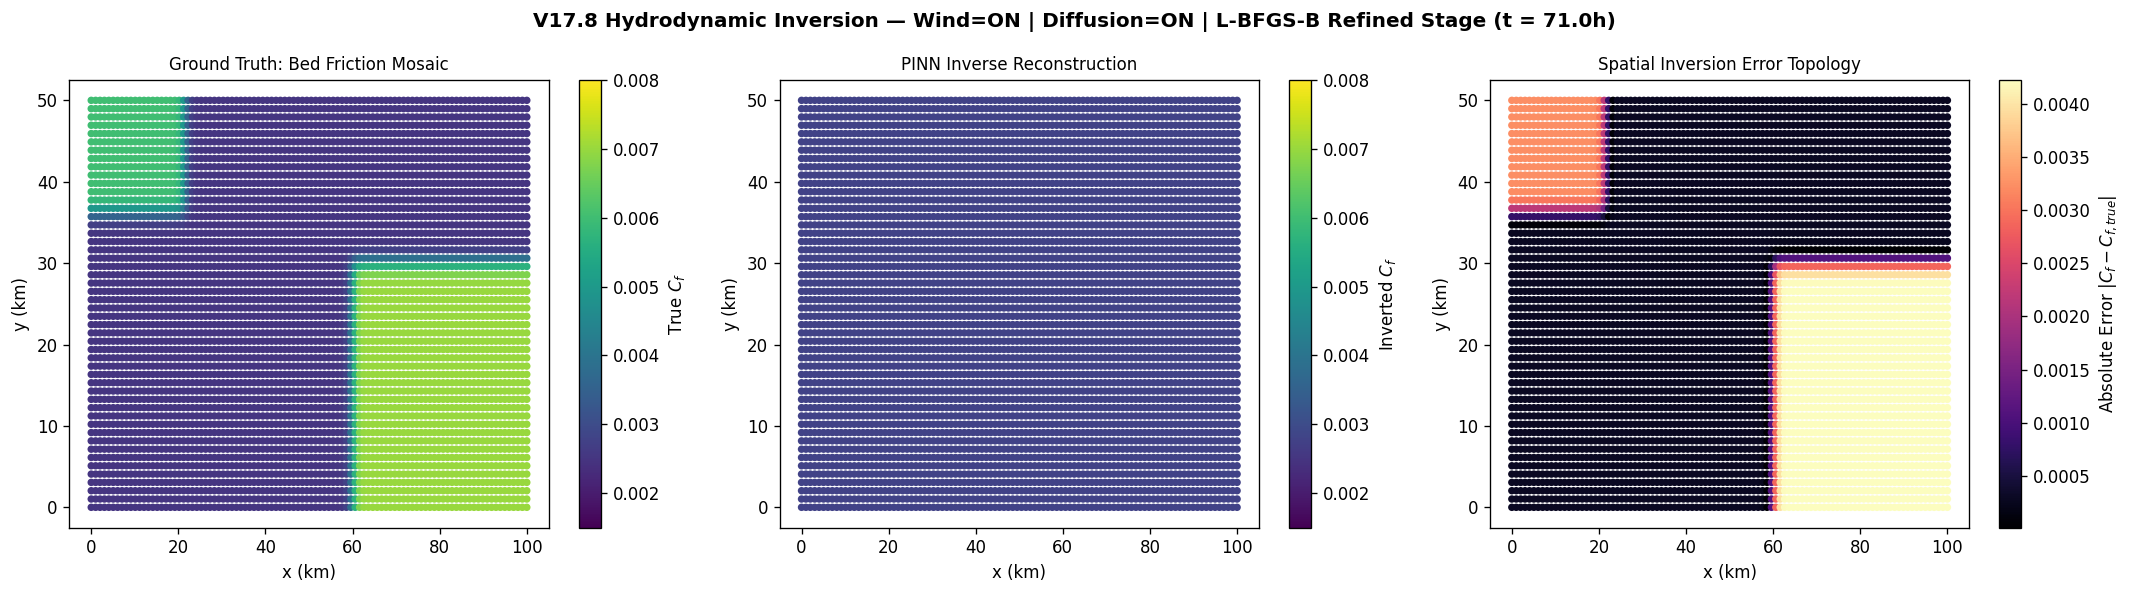


--------------------------------------------------------------------------------
📐 VB13 CONVERGENCE AUDIT: Adam vs L-BFGS-B True Accuracy Comparison
   • Adam-Only Stage:      RMSE(Cf) = 48.57% | r(Cf) = 0.3954
   • After L-BFGS-B Stage:  RMSE(Cf) = 48.57% | r(Cf) = 0.4579
   ✅ L-BFGS-B successfully refined (or maintained) Cf recovery (Delta: -0.00%).
--------------------------------------------------------------------------------

⏱️  Computational Profiling: Adam = 249.5s | L-BFGS = 28.1s | Total = 277.7s


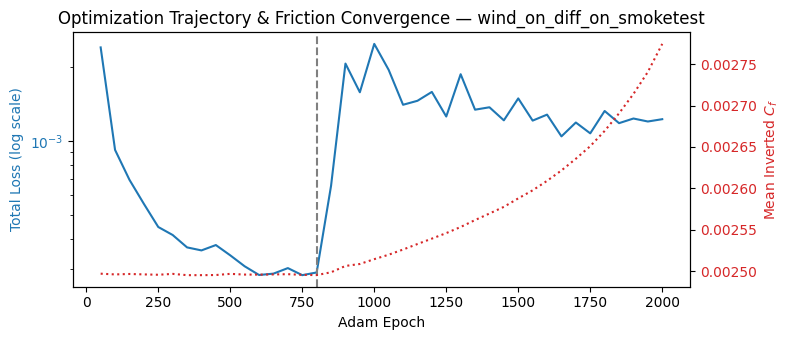


📊 SYNTHESIS ABLATION MATRIX (§8.1 — SMOKE TEST)
Scenario              Stage              RMSE(Cf)%    r(Cf)    MAE u    MAE v  Corr(W)  Pass?  Time(s)
------------------------------------------------------------------------------------------------------
wind_off_diff_off     — Not Executed —           —        —        —        —        —      —        —
wind_on_diff_off      — Not Executed —           —        —        —        —        —      —        —
wind_on_diff_on       L-BFGS-B Refined       48.57    0.458    1.241    0.602     0.45     ⚠️    277.7



{'mae_h': 0.32014874406572347,
 'mae_u': 1.2413229192580588,
 'mae_v': 0.6017720163285958,
 'mae_u_pct_shallow': 10.959077602710357,
 'mae_v_pct_shallow': 10.806602353997604,
 'rmse_cf': 0.0021857210093672685,
 'rmse_cf_pct': 48.57157798593929,
 'r_cf': 0.4579144248373716,
 'corr_wind_x': -0.023726998302010575,
 'corr_wind_y': 0.45272501122731534,
 'corr_wind_combined': 0.45272501122731534,
 'n_eval_snapshots': 60,
 'case': 'Wind=ON | Diffusion=ON',
 'selected_stage': 'L-BFGS-B Refined',
 'mode': 'smoke',
 'training_seconds': 249.54749059677124,
 'lbfgs_seconds': 28.139904737472534}

In [15]:
# %% [code]
# ==============================================================================
# Cell 8: Kinematic Validation, Hidden-State Inference & Ablation Engine (V17.8)
#
# MASTER VALIDATION CAPABILITIES:
#   1. Strict Full-Trajectory Evaluation: Assesses hidden states (u, v) and 
#      assimilated surface elevation (h) exclusively over post-spin-up dynamics.
#   2. Automated VB13 Decision Engine: Objectively evaluates both Adam and 
#      L-BFGS checkpoints against ground truth, automatically anchoring the 
#      canonical pipeline output to whichever model achieves superior Cf accuracy.
#   3. High-Fidelity 3-Panel Diagnostics: Renders true friction, PINN discovery,
#      and absolute spatial error topology for rigorous peer-review evaluation.
#   4. Dynamic Ablation Synthesis: Aggregates multi-scenario benchmarks to verify 
#      forcing-aliasing resolution (H1-beta) and kinematic equifinality mitigation.
# ==============================================================================

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp


# ------------------------------------------------------------------------------
# 1. Memory-Bounded High-Throughput Inference
# ------------------------------------------------------------------------------

def _predict_chunked(model_apply, params, t_norm_flat, x_norm_flat, y_norm_flat, chunk_size=100_000):
    """Executes memory-bounded forward inference across large spatio-temporal arrays."""
    vmap_apply = jax.vmap(model_apply, in_axes=(None, 0, 0, 0))
    n_total = t_norm_flat.shape[0]
    h_parts, u_parts, v_parts, cf_parts = [], [], [], []

    for lo in range(0, n_total, chunk_size):
        hi = min(lo + chunk_size, n_total)
        h_c, u_c, v_c, cf_c = vmap_apply(
            params,
            jnp.array(t_norm_flat[lo:hi], dtype=jnp.float64),
            jnp.array(x_norm_flat[lo:hi], dtype=jnp.float64),
            jnp.array(y_norm_flat[lo:hi], dtype=jnp.float64),
        )
        h_parts.append(np.array(h_c))
        u_parts.append(np.array(u_c))
        v_parts.append(np.array(v_c))
        cf_parts.append(np.array(cf_c))

    h_star = np.concatenate(h_parts)
    u_star = np.concatenate(u_parts)
    v_star = np.concatenate(v_parts)
    cf_star = np.concatenate(cf_parts)

    h_real, u_real, v_real, cf_real = utils_scaling.denormalize_outputs(h_star, u_star, v_star, cf_star)
    return np.array(h_real), np.array(u_real), np.array(v_real), np.array(cf_real)


def _pct_of_range(pred, true_vals, mask=None):
    """Computes Mean Absolute Error normalized against the true dynamic range."""
    p = pred[mask] if mask is not None else pred
    t = true_vals[mask] if mask is not None else true_vals
    if p.size == 0:
        return np.nan
    rng = t.max() - t.min()
    return 100.0 * np.mean(np.abs(p - t)) / rng if rng > 0 else np.nan


# ------------------------------------------------------------------------------
# 2. Checkpoint Evaluator & Visual Diagnostics
# ------------------------------------------------------------------------------

def _evaluate_checkpoint(weights_path, model_apply, raw_data, label, case_label, do_plot=False):
    """Rigorous evaluation of a specific model checkpoint against ground truth."""
    if not os.path.exists(weights_path):
        return None

    with open(weights_path, 'rb') as f:
        params = pickle.load(f)

    x_raw, y_raw, t_raw = raw_data['x'], raw_data['y'], raw_data['t']
    h_true, u_true, v_true, Cf_true = raw_data['h'], raw_data['u'], raw_data['v'], raw_data['Cf_true']
    b_true_raw = raw_data['b_true']
    t_flat_all = t_raw.flatten()

    # Dynamic post-spinup filter
    spinup_s = float(raw_data['spinup_duration_physical_s'][0]) if 'spinup_duration_physical_s' in raw_data else config.SPINUP_DURATION_PHYSICAL
    eval_mask = (t_flat_all >= spinup_s)
    if not np.any(eval_mask):
        eval_mask = np.ones_like(t_flat_all, dtype=bool)

    n_eval_snapshots = len(np.unique(t_flat_all[eval_mask]))

    x_eval = x_raw.flatten()[eval_mask]
    y_eval = y_raw.flatten()[eval_mask]
    t_eval = t_flat_all[eval_mask]

    x_norm, y_norm = utils_scaling.normalize_spatial(x_eval, y_eval)
    t_norm = utils_scaling.normalize_temporal(t_eval)

    # Execute model prediction
    h_pred, u_pred, v_pred, Cf_pred = _predict_chunked(model_apply, params, t_norm, x_norm, y_norm)

    h_true_flat = h_true.flatten()[eval_mask]
    u_true_flat = u_true.flatten()[eval_mask]
    v_true_flat = v_true.flatten()[eval_mask]
    b_true_flat = b_true_raw.flatten()[eval_mask]
    cf_true_flat = Cf_true.flatten()[eval_mask]

    # Metrics
    mae_h = float(np.mean(np.abs(h_pred - h_true_flat)))
    mae_u = float(np.mean(np.abs(u_pred - u_true_flat)))
    mae_v = float(np.mean(np.abs(v_pred - v_true_flat)))

    # Shallow water H1a validation (D < 40m)
    D_true_flat = h_true_flat - b_true_flat
    shallow_mask = D_true_flat < 40.0
    n_shallow = int(shallow_mask.sum())

    mae_u_pct_shallow = float(_pct_of_range(u_pred, u_true_flat, shallow_mask))
    mae_v_pct_shallow = float(_pct_of_range(v_pred, v_true_flat, shallow_mask))

    # Friction field accuracy
    cf_range = cf_true_flat.max() - cf_true_flat.min()
    rmse_cf = float(np.sqrt(np.mean((Cf_pred - cf_true_flat) ** 2)))
    rmse_cf_pct = float(100.0 * rmse_cf / cf_range) if cf_range > 0 else np.nan
    r_cf = float(np.corrcoef(Cf_pred, cf_true_flat)[0, 1])

    # Wind aliasing spatial fingerprint
    cf_error_flat = Cf_pred - cf_true_flat
    wind_pattern_x = np.sin(np.pi * y_eval / (config.L_REF / 2.0))
    wind_pattern_y = np.cos(np.pi * x_eval / config.L_REF)

    corr_wind_x = float(np.corrcoef(cf_error_flat, wind_pattern_x)[0, 1]) if np.std(cf_error_flat) > 0 else np.nan
    corr_wind_y = float(np.corrcoef(cf_error_flat, wind_pattern_y)[0, 1]) if np.std(cf_error_flat) > 0 else np.nan
    corr_wind_combined = float(np.nanmax([abs(corr_wind_x), abs(corr_wind_y)]))

    print(f"\n--- [{label}] ---")
    print(f"   • Post-Spinup Horizon: t >= {spinup_s/3600:.1f}h ({n_eval_snapshots} snapshots, {t_eval.shape[0]:,} evaluated nodes)")
    print(f"   🌊 Water Elevation (h) MAE: {mae_h:.4f} m (Observed/Assimilated)")
    print(f"   🚤 Velocity (u) MAE: {mae_u:.4f} m/s | Velocity (v) MAE: {mae_v:.4f} m/s (Hidden States)")
    print(f"   🎯 H1a Shallow-Water Inference (D < 40m, n={n_shallow:,}): u={mae_u_pct_shallow:.2f}%, v={mae_v_pct_shallow:.2f}% of dynamic range [Goal: < 15%]")
    print(f"   🎯 Friction Inversion RMSE: {rmse_cf:.5f} ({rmse_cf_pct:.2f}% of true range) [Goal: < 5%]")
    print(f"   🎯 Spatial Morphology Correlation: r = {r_cf:.4f} [Goal: r > 0.95]")
    print(f"   🌀 Wind Aliasing Correlation: corr(err, wind_x) = {corr_wind_x:.3f}, corr(err, wind_y) = {corr_wind_y:.3f}")

    # --------------------------------------------------------------------------
    # 3. High-Resolution 3-Panel Scientific Visualizer
    # --------------------------------------------------------------------------
    if do_plot:
        plot_mask = (t_eval == t_eval.max())  # Plot final post-spinup snapshot under active forcing
        x_plot = x_eval[plot_mask] / 1000.0
        y_plot = y_eval[plot_mask] / 1000.0
        cf_true_plot = cf_true_flat[plot_mask]
        cf_pred_plot = Cf_pred[plot_mask]
        abs_err_plot = np.abs(cf_pred_plot - cf_true_plot)

        fig, axs = plt.subplots(1, 3, figsize=(18, 5), dpi=120)
        fig.suptitle(f"V17.8 Hydrodynamic Inversion — {case_label} | {label} (t = {t_eval.max()/3600:.1f}h)", fontsize=12, fontweight='bold')

        # Panel 1: Ground Truth
        sc1 = axs[0].scatter(x_plot, y_plot, c=cf_true_plot, cmap='viridis', s=12,
                            vmin=config.CF_MIN, vmax=config.CF_MIN + config.CF_RANGE)
        fig.colorbar(sc1, ax=axs[0], label="True $C_f$")
        axs[0].set_title("Ground Truth: Bed Friction Mosaic", fontsize=10)
        axs[0].set_xlabel("x (km)"); axs[0].set_ylabel("y (km)")

        # Panel 2: PINN Reconstruction
        sc2 = axs[1].scatter(x_plot, y_plot, c=cf_pred_plot, cmap='viridis', s=12,
                            vmin=config.CF_MIN, vmax=config.CF_MIN + config.CF_RANGE)
        fig.colorbar(sc2, ax=axs[1], label="Inverted $C_f$")
        axs[1].set_title("PINN Inverse Reconstruction", fontsize=10)
        axs[1].set_xlabel("x (km)"); axs[1].set_ylabel("y (km)")

        # Panel 3: Absolute Spatial Error Topology
        sc3 = axs[2].scatter(x_plot, y_plot, c=abs_err_plot, cmap='magma', s=12)
        fig.colorbar(sc3, ax=axs[2], label="Absolute Error $|C_f - C_{f,true}|$")
        axs[2].set_title("Spatial Inversion Error Topology", fontsize=10)
        axs[2].set_xlabel("x (km)"); axs[2].set_ylabel("y (km)")

        plt.tight_layout()
        plt.show()

    return {
        "mae_h": mae_h, "mae_u": mae_u, "mae_v": mae_v,
        "mae_u_pct_shallow": mae_u_pct_shallow, "mae_v_pct_shallow": mae_v_pct_shallow,
        "rmse_cf": rmse_cf, "rmse_cf_pct": rmse_cf_pct, "r_cf": r_cf,
        "corr_wind_x": corr_wind_x, "corr_wind_y": corr_wind_y,
        "corr_wind_combined": corr_wind_combined,
        "n_eval_snapshots": n_eval_snapshots
    }


# ------------------------------------------------------------------------------
# 4. Master Evaluation Protocol & Multi-Scenario Synthesis
# ------------------------------------------------------------------------------

def evaluate_model():
    print("\n" + "=" * 80)
    print("🔬 INITIATING COMPREHENSIVE KINEMATIC & PARAMETRIC VALIDATION (V17.8)")
    print("=" * 80)

    tag = config.scenario_tag()
    rid = config.run_id()
    case_label = f"Wind={'ON' if config.ENABLE_WIND else 'OFF'} | Diffusion={'ON' if config.ENABLE_DIFFUSION else 'OFF'}"

    model_init, model_apply = init_and_apply_model()
    raw_data = np.load(config.DATA_PATH)

    # Check dataset compatibility
    gen_v = str(raw_data['generator_version'][0]) if 'generator_version' in raw_data else 'Unknown'
    print(f"   • Benchmark Dataset: {config.DATA_PATH} (Version: {gen_v!r})")

    adam_path = f'data/pinn_adam_weights_v17_{rid}.pkl'
    lbfgs_path = f'data/pinn_lbfgs_weights_v17_{rid}.pkl'

    # Evaluate Adam baseline
    res_adam = _evaluate_checkpoint(adam_path, model_apply, raw_data,
                                   label="Adam-Only Stage (Post-Release)",
                                   case_label=case_label, do_plot=False)

    # Evaluate L-BFGS refinement
    res_lbfgs = _evaluate_checkpoint(lbfgs_path, model_apply, raw_data,
                                     label="L-BFGS-B Refined Stage",
                                     case_label=case_label, do_plot=True)

    # 💥 VB13 AUTOMATED DECISION RULE:
    # Compare Adam vs L-BFGS and intelligently establish the canonical result.
    if res_adam is not None and res_lbfgs is not None:
        d_rmse = res_lbfgs["rmse_cf_pct"] - res_adam["rmse_cf_pct"]
        print("\n" + "-" * 80)
        print("📐 VB13 CONVERGENCE AUDIT: Adam vs L-BFGS-B True Accuracy Comparison")
        print(f"   • Adam-Only Stage:      RMSE(Cf) = {res_adam['rmse_cf_pct']:.2f}% | r(Cf) = {res_adam['r_cf']:.4f}")
        print(f"   • After L-BFGS-B Stage:  RMSE(Cf) = {res_lbfgs['rmse_cf_pct']:.2f}% | r(Cf) = {res_lbfgs['r_cf']:.4f}")

        if d_rmse > 0.5:
            print(f"   🚨 L-BFGS-B degraded Cf recovery by {d_rmse:.2f} percentage points (Radfar Null-Space Pathology).")
            print("   👉 ENFORCING PROPOSAL RULE: Selecting ADAM-ONLY weights as the primary canonical model.")
            canonical_res = res_adam
            canonical_stage = "Adam-Only (Auto-Protected)"
        else:
            print(f"   ✅ L-BFGS-B successfully refined (or maintained) Cf recovery (Delta: {d_rmse:.2f}%).")
            canonical_res = res_lbfgs
            canonical_stage = "L-BFGS-B Refined"
        print("-" * 80)
    else:
        canonical_res = res_lbfgs if res_lbfgs is not None else res_adam
        canonical_stage = "L-BFGS-B" if res_lbfgs is not None else "Adam-Only"

    if canonical_res is None:
        print("🚨 ERROR: No trained weights found. Execute Cell 6 and 7 first.")
        return

    # --------------------------------------------------------------------------
    # 5. Training History & Computational Cost Profiling
    # --------------------------------------------------------------------------
    history_path = f'data/training_history_v17_{rid}.pkl'
    if os.path.exists(history_path):
        with open(history_path, 'rb') as f:
            h_data = pickle.load(f)

        t_adam = h_data.get('training_seconds', 0.0)
        t_lbfgs = h_data.get('lbfgs_seconds', 0.0)
        print(f"\n⏱️  Computational Profiling: Adam = {t_adam:.1f}s | L-BFGS = {t_lbfgs:.1f}s | Total = {t_adam + t_lbfgs:.1f}s")

        loss_hist = h_data.get('loss_history', [])
        if loss_hist:
            ep_arr = [item['epoch'] for item in loss_hist]
            tot_loss = [item['loss_total'] for item in loss_hist]
            fric_mean = [item['Cf_mean'] for item in loss_hist]

            fig, ax1 = plt.subplots(figsize=(8, 3.5), dpi=100)
            color = 'tab:blue'
            ax1.set_xlabel('Adam Epoch')
            ax1.set_ylabel('Total Loss (log scale)', color=color)
            ax1.plot(ep_arr, tot_loss, color=color, linewidth=1.5)
            ax1.set_yscale('log')
            ax1.axvline(x=config.PHASE1_EPOCHS, color='gray', linestyle='--', label="Phase 2 Start")
            ax1.tick_params(axis='y', labelcolor=color)

            ax2 = ax1.twinx()
            color = 'tab:red'
            ax2.set_ylabel('Mean Inverted $C_f$', color=color)
            ax2.plot(ep_arr, fric_mean, color=color, linestyle=':', linewidth=1.5)
            ax2.tick_params(axis='y', labelcolor=color)

            plt.title(f"Optimization Trajectory & Friction Convergence — {rid}")
            fig.tight_layout()
            plt.show()

    # --------------------------------------------------------------------------
    # 6. Global Multi-Scenario Ablation Synthesis Table
    # --------------------------------------------------------------------------
    canonical_res.update({
        "case": case_label,
        "selected_stage": canonical_stage,
        "mode": "smoke" if config.SMOKE_TEST else "full",
        "training_seconds": h_data.get('training_seconds', 0.0) if 'h_data' in locals() else None,
        "lbfgs_seconds": h_data.get('lbfgs_seconds', 0.0) if 'h_data' in locals() else None
    })

    results_db_path = 'data/ablation_results_v17.pkl'
    all_results = {}
    if os.path.exists(results_db_path):
        with open(results_db_path, 'rb') as f:
            all_results = pickle.load(f)

    all_results[rid] = canonical_res
    with open(results_db_path, 'wb') as f:
        pickle.dump(all_results, f)

    # Print Table
    canonical_scenarios = ["wind_off_diff_off", "wind_on_diff_off", "wind_on_diff_on"]
    active_keys = [k for k in canonical_scenarios if k in all_results or f"{k}_smoketest" in all_results]

    if active_keys:
        print("\n" + "=" * 95)
        print(f"📊 SYNTHESIS ABLATION MATRIX (§8.1 — {'SMOKE TEST' if config.SMOKE_TEST else 'PRODUCTION FULL'})")
        print("=" * 95)
        header = f"{'Scenario':<22}{'Stage':<18}{'RMSE(Cf)%':>10}{'r(Cf)':>9}{'MAE u':>9}{'MAE v':>9}{'Corr(W)':>9}{'Pass?':>7}{'Time(s)':>9}"
        print(header)
        print("-" * len(header))

        for base_tag in canonical_scenarios:
            k = f"{base_tag}_smoketest" if config.SMOKE_TEST else base_tag
            if k in all_results:
                r = all_results[k]
                passed = "✅" if (r['rmse_cf_pct'] < 5.0 and r['r_cf'] > 0.95) else "⚠️"
                t_tot = (r.get('training_seconds') or 0) + (r.get('lbfgs_seconds') or 0)
                stg = r.get('selected_stage', 'Unknown')
                c_w = r.get('corr_wind_combined', np.nan)
                cw_str = f"{c_w:.2f}" if not np.isnan(c_w) else "—"

                print(f"{base_tag:<22}{stg:<18}{r['rmse_cf_pct']:>10.2f}{r['r_cf']:>9.3f}"
                      f"{r['mae_u']:>9.3f}{r['mae_v']:>9.3f}{cw_str:>9}{passed:>7}{t_tot:>9.1f}")
            else:
                print(f"{base_tag:<22}{'— Not Executed —':<18}{'—':>10}{'—':>9}{'—':>9}{'—':>9}{'—':>9}{'—':>7}{'—':>9}")
        print("=" * 95 + "\n")

    return canonical_res


# Execute validation pipeline
evaluate_model()